In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import cv2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("✅ Done !!")

✅ Done !!


In [2]:
train_dir = "L:/ML/𝑮𝒓𝒂𝒅𝒖𝒂𝒕𝒊𝒐𝒏 𝒑𝒓𝒐𝒋/Datasets/archive/Teeth_DataSet/Teeth_Dataset/Training"
val_dir = "L:/ML/𝑮𝒓𝒂𝒅𝒖𝒂𝒕𝒊𝒐𝒏 𝒑𝒓𝒐𝒋/Datasets/archive/Teeth_DataSet/Teeth_Dataset/Validation"
test_dir = "L:/ML/𝑮𝒓𝒂𝒅𝒖𝒂𝒕𝒊𝒐𝒏 𝒑𝒓𝒐𝒋/Datasets/archive/Teeth_DataSet/Teeth_Dataset/Testing"

def check_directory_structure():
    print("🔍 !!")
    
    directories = {
        'Training': train_dir,
        'Validation': val_dir, 
        'Testing': test_dir
    }
    
    actual_classes = []
    
    for name, path in directories.items():
        print(f"\n{name} Directory: {path}")
        if os.path.exists(path):
            subdirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
            print(f"folders located in {name}: {subdirs}")
            
            if not actual_classes:
                actual_classes = subdirs
            
            for subdir in subdirs:
                subdir_path = os.path.join(path, subdir)
                if os.path.isdir(subdir_path):
                    image_files = [f for f in os.listdir(subdir_path) 
                                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                    print(f"  {subdir}: {len(image_files)} images")
        else:
            print(f"❌ المجلد غير موجود: {path}")
    
    return actual_classes


actual_class_folders = check_directory_structure()

🔍 !!

Training Directory: L:/ML/𝑮𝒓𝒂𝒅𝒖𝒂𝒕𝒊𝒐𝒏 𝒑𝒓𝒐𝒋/Datasets/archive/Teeth_DataSet/Teeth_Dataset/Training
folders located in Training: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
  CaS: 480 images
  CoS: 450 images
  Gum: 360 images
  MC: 540 images
  OC: 324 images
  OLP: 540 images
  OT: 393 images

Validation Directory: L:/ML/𝑮𝒓𝒂𝒅𝒖𝒂𝒕𝒊𝒐𝒏 𝒑𝒓𝒐𝒋/Datasets/archive/Teeth_DataSet/Teeth_Dataset/Validation
folders located in Validation: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
  CaS: 160 images
  CoS: 149 images
  Gum: 120 images
  MC: 180 images
  OC: 108 images
  OLP: 180 images
  OT: 131 images

Testing Directory: L:/ML/𝑮𝒓𝒂𝒅𝒖𝒂𝒕𝒊𝒐𝒏 𝒑𝒓𝒐𝒋/Datasets/archive/Teeth_DataSet/Teeth_Dataset/Testing
folders located in Testing: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
  CaS: 160 images
  CoS: 149 images
  Gum: 120 images
  MC: 180 images
  OC: 108 images
  OLP: 180 images
  OT: 131 images


In [ ]:
# Cell 3: Define class mapping
# Create mapping between folder names and descriptive names
class_mapping = {
    'CaS': 'Candidiasis',
    'CoS': 'Commissural Stomatitis', 
    'Gum': 'Gum Disease / Gingivitis',
    'MC': 'Mucocele',
    'OC': 'Oral Cancer',
    'OLP': 'Oral Lichen Planus',
    'OT': 'Other'
}

print(f"📋 Folder to class mapping:")
for folder_name, class_name in class_mapping.items():
    print(f"  {folder_name} → {class_name}")


class_names = list(class_mapping.values())
print(f"\n🎯 Target classes: {class_names}")

📋 Folder to class mapping:
  CaS → Candidiasis
  CoS → Commissural Stomatitis
  Gum → Gum Disease / Gingivitis
  MC → Mucocele
  OC → Oral Cancer
  OLP → Oral Lichen Planus
  OT → Other

🎯 Target classes: ['Candidiasis', 'Commissural Stomatitis', 'Gum Disease / Gingivitis', 'Mucocele', 'Oral Cancer', 'Oral Lichen Planus', 'Other']


In [ ]:
# Cell 4: Create data generators
def create_data_generators():
    print("📁 Preparing data generators...")
    
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    
    val_test_datagen = ImageDataGenerator(rescale=1./255)
    
    try:
        print("Loading training data...")
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(224, 224),
            batch_size=32,
            class_mode='categorical'
        )
        
        print("Loading validation data...")
        validation_generator = val_test_datagen.flow_from_directory(
            val_dir,
            target_size=(224, 224),
            batch_size=32,
            class_mode='categorical'
        )
        
        print("Loading test data...")
        test_generator = val_test_datagen.flow_from_directory(
            test_dir,
            target_size=(224, 224),
            batch_size=32,
            class_mode='categorical',
            shuffle=False
        )
        
        print(f"✅ Loaded {train_generator.samples} training images")
        print(f"✅ Loaded {validation_generator.samples} validation images") 
        print(f"✅ Loaded {test_generator.samples} test images")
        
        # Show class mapping discovered by generator
        print(f"\n📊 Classes discovered: {train_generator.class_indices}")
        
        return train_generator, validation_generator, test_generator
        
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None, None, None


train_gen, val_gen, test_gen = create_data_generators()

📁 Preparing data generators...
Loading training data...
Found 3087 images belonging to 7 classes.
Loading validation data...
Found 1028 images belonging to 7 classes.
Loading test data...
Found 1028 images belonging to 7 classes.
✅ Loaded 3087 training images
✅ Loaded 1028 validation images
✅ Loaded 1028 test images

📊 Classes discovered: {'CaS': 0, 'CoS': 1, 'Gum': 2, 'MC': 3, 'OC': 4, 'OLP': 5, 'OT': 6}


🖼️ Displaying sample images...


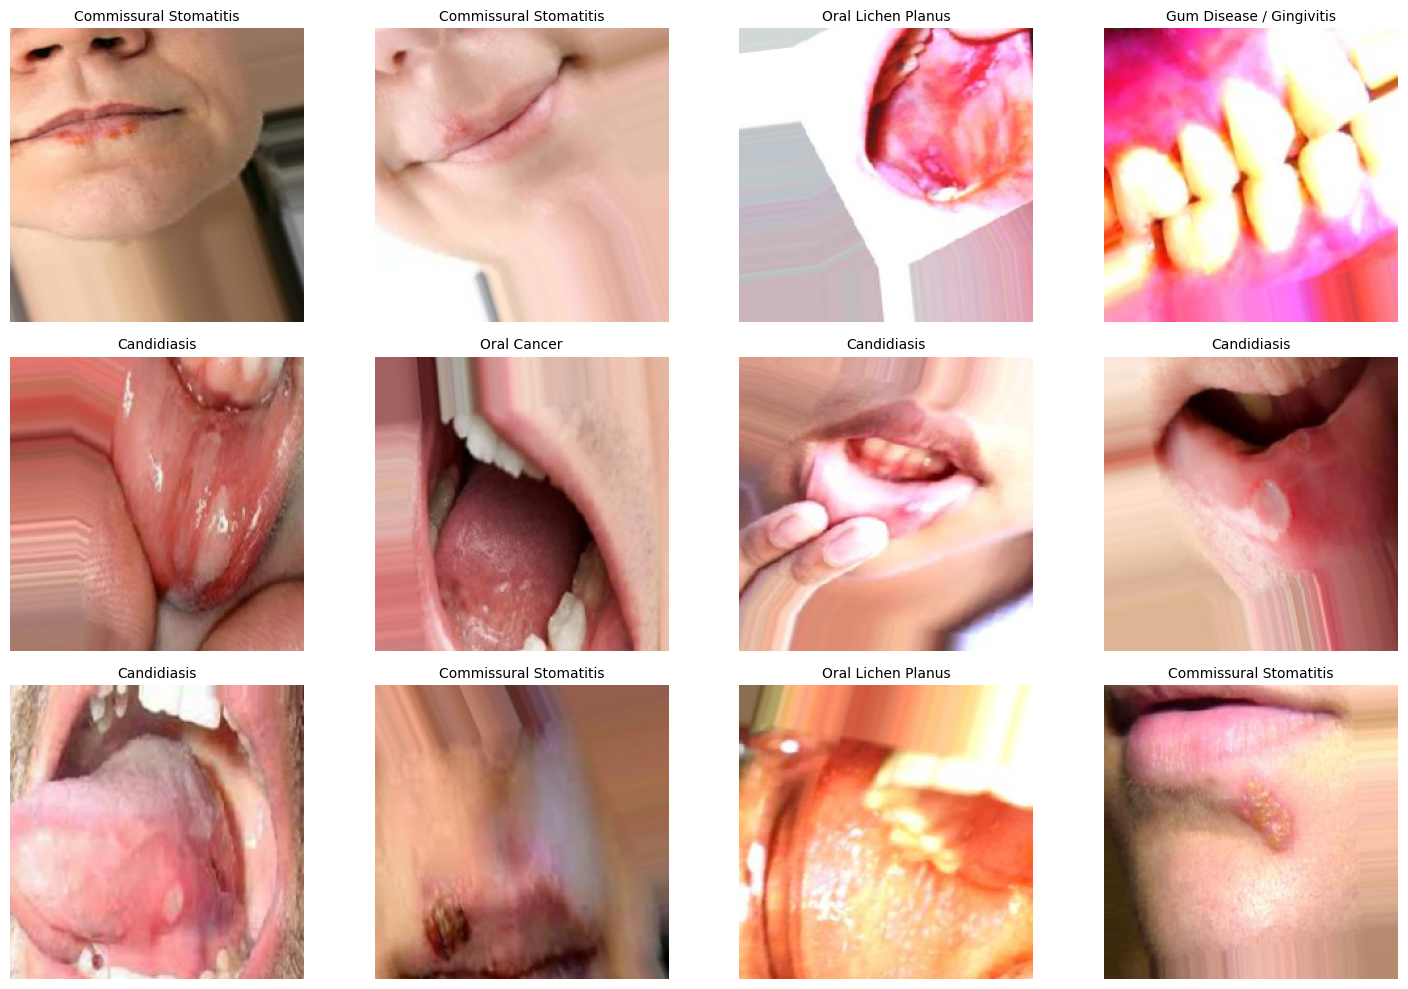

In [5]:
# Cell 5: Display sample images
def display_sample_images(generator, class_mapping):
    print("🖼️ Displaying sample images...")
    
    # Get a batch of data
    x_batch, y_batch = next(generator)
    
    # Reverse class_indices
    idx_to_class = {v: k for k, v in generator.class_indices.items()}
    
    # Create figure
    plt.figure(figsize=(15, 10))
    
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(x_batch[i])
        
        # Get true class
        true_class_idx = np.argmax(y_batch[i])
        folder_name = idx_to_class[true_class_idx]
        class_name = class_mapping.get(folder_name, folder_name)
        
        plt.title(f'{class_name}', fontsize=10)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if train_gen is not None:
    display_sample_images(train_gen, class_mapping)

In [6]:
# Cell 6: Build CNN model
def create_cnn_model(num_classes):
    print(f"🧠 Building model with {num_classes} classes...")
    
    model = keras.Sequential([
        # First convolutional layers
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        # Second convolutional layers
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        # Third convolutional layers
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        # Fourth convolutional layers
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        # Fully Connected layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

if train_gen is not None:
    num_classes = len(train_gen.class_indices)
    model = create_cnn_model(num_classes)
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print("📊 Model summary:")
    model.summary()

🧠 Building model with 7 classes...


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


📊 Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 19,401,415 (74.01 MB)

 Trainable params: 19,398,919 (74.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [7]:
# Cell 7: Train the model
def train_model(model, train_gen, val_gen):
    print("🚀 Starting training...")
    
    # Callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(
            patience=10, 
            restore_best_weights=True,
            monitor='val_accuracy'
        ),
        keras.callbacks.ReduceLROnPlateau(
            factor=0.2, 
            patience=5,
            monitor='val_loss'
        ),
        keras.callbacks.ModelCheckpoint(
            'best_oral_disease_model.h5', 
            save_best_only=True,
            monitor='val_accuracy'
        )
    ]
    
    # Training
    history = model.fit(
        train_gen,
        epochs=100,
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1
    )
    
    return history

if train_gen is not None and val_gen is not None:
    history = train_model(model, train_gen, val_gen)
else:
    print("❌ Cannot start training - data not available")
    history = None

🚀 Starting training...
Epoch 1/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2180 - loss: 2.5717

97/97 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.2420 - loss: 2.3492 - val_accuracy: 0.1897 - val_loss: 4.4412 - learning_rate: 0.0010
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.3077 - loss: 1.9676 - val_accuracy: 0.1459 - val_loss: 4.8302 - learning_rate: 0.0010
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.3780 - loss: 1.7301 - val_accuracy: 0.1479 - val_loss: 6.3242 - learning_rate: 0.0010
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4076 - loss: 1.6524

97/97 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.4088 - loss: 1.6204 - val_accuracy: 0.2364 - val_loss: 2.9659 - learning_rate: 0.0010
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.4357 - loss: 1.5070 - val_accuracy: 0.1868 - val_loss: 4.4298 - learning_rate: 0.0010
Epoch 6/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4676 - loss: 1.4377

97/97 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.4674 - loss: 1.4347 - val_accuracy: 0.2772 - val_loss: 1.8834 - learning_rate: 0.0010
Epoch 7/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4848 - loss: 1.3511

97/97 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.5037 - loss: 1.3270 - val_accuracy: 0.3784 - val_loss: 1.7912 - learning_rate: 0.0010
Epoch 8/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5044 - loss: 1.3120

...

97/97 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.9096 - loss: 0.2682 - val_accuracy: 0.9815 - val_loss: 0.0782 - learning_rate: 2.0000e-04
Epoch 49/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.9002 - loss: 0.2724 - val_accuracy: 0.9679 - val_loss: 0.1224 - learning_rate: 2.0000e-04
Epoch 50/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.9067 - loss: 0.2585 - val_accuracy: 0.9786 - val_loss: 0.0896 - learning_rate: 2.0000e-04
Epoch 51/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9158 - loss: 0.2314

97/97 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.9184 - loss: 0.2436 - val_accuracy: 0.9825 - val_loss: 0.0711 - learning_rate: 2.0000e-04
Epoch 52/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9215 - loss: 0.2250

97/97 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.9171 - loss: 0.2395 - val_accuracy: 0.9874 - val_loss: 0.0590 - learning_rate: 2.0000e-04
Epoch 53/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.9206 - loss: 0.2302 - val_accuracy: 0.9737 - val_loss: 0.0885 - learning_rate: 2.0000e-04
Epoch 54/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.9180 - loss: 0.2320 - val_accuracy: 0.9874 - val_loss: 0.0640 - learning_rate: 2.0000e-04
Epoch 55/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.9132 - loss: 0.2364 - val_accuracy: 0.9796 - val_loss: 0.0689 - learning_rate: 2.0000e-04
Epoch 56/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.9213 - loss: 0.2273 - val_accuracy: 0.8609 - val_loss: 0.4192 - learning_rate: 2.0000e-04
Epoch 57/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9209 - loss: 0.2342

97/97 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.9255 - loss: 0.2179 - val_accuracy: 0.9883 - val_loss: 0.0501 - learning_rate: 2.0000e-04
Epoch 58/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.9242 - loss: 0.2251 - val_accuracy: 0.9805 - val_loss: 0.0746 - learning_rate: 2.0000e-04
Epoch 59/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.9261 - loss: 0.2196 - val_accuracy: 0.6848 - val_loss: 1.2581 - learning_rate: 2.0000e-04
Epoch 60/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.9232 - loss: 0.2268 - val_accuracy: 0.9854 - val_loss: 0.0575 - learning_rate: 2.0000e-04
Epoch 61/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9206 - loss: 0.2245

97/97 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.9193 - loss: 0.2300 - val_accuracy: 0.9922 - val_loss: 0.0425 - learning_rate: 2.0000e-04
Epoch 62/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.9190 - loss: 0.2295 - val_accuracy: 0.9883 - val_loss: 0.0602 - learning_rate: 2.0000e-04
Epoch 63/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.9346 - loss: 0.1925 - val_accuracy: 0.9874 - val_loss: 0.0624 - learning_rate: 2.0000e-04
Epoch 64/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.9320 - loss: 0.1960 - val_accuracy: 0.9835 - val_loss: 0.0640 - learning_rate: 2.0000e-04
Epoch 65/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.9336 - loss: 0.2020 - val_accuracy: 0.9854 - val_loss: 0.0572 - learning_rate: 2.0000e-04
Epoch 66/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.9300 - loss: 0.2025 - val_accuracy: 0.9912 - val_loss: 0.0410 - learning_rate: 2.0000e-04
Epoch 67/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.9339

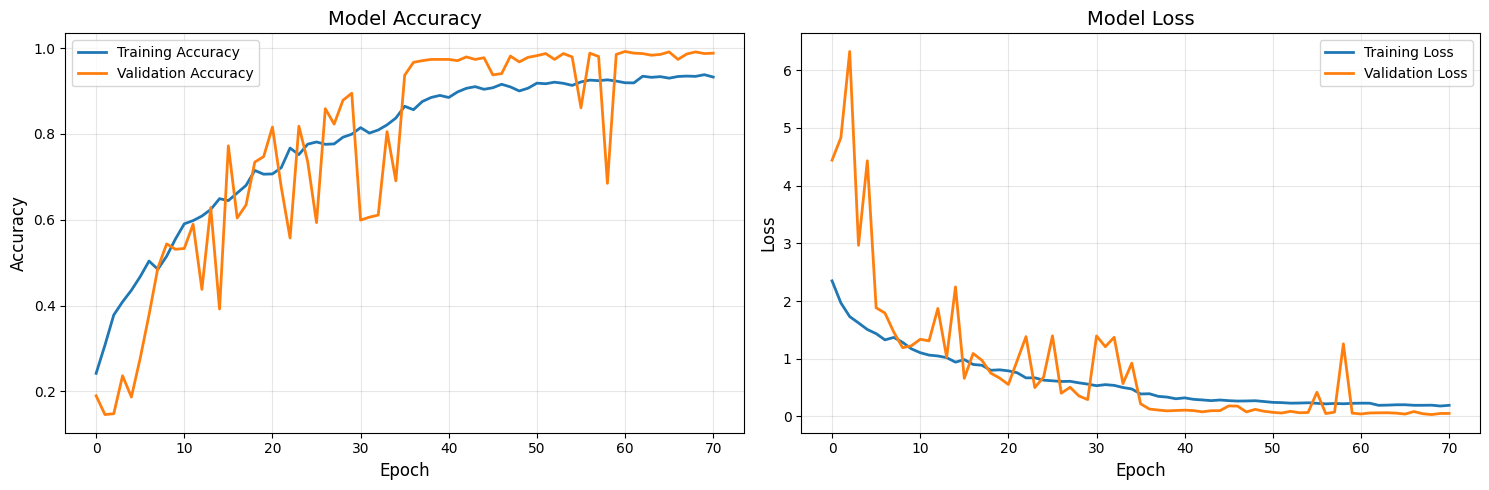

In [8]:
# Cell 8: Plot training results
def plot_training_history(history):
    if history is None:
        print("❌ No data to plot")
        return
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot training and validation accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot training and validation loss
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [9]:
# Cell 9: Evaluate model on test data
def evaluate_model(model, test_gen, class_mapping):
    if test_gen is None:
        print("❌ Test data not available")
        return
    
    print("Evaluating model on test data...")
    
    # Evaluation
    test_loss, test_accuracy = model.evaluate(test_gen)
    print(f"\n🎯 Test Accuracy: {test_accuracy:.4f}")
    print(f"📉 Test Loss: {test_loss:.4f}")
    
    # Predictions
    predictions = model.predict(test_gen)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_gen.classes
    
    # Reverse class_indices
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    
    # Convert numbers to descriptive names
    true_class_names = [class_mapping.get(idx_to_class[cls], idx_to_class[cls]) for cls in true_classes]
    predicted_class_names = [class_mapping.get(idx_to_class[cls], idx_to_class[cls]) for cls in predicted_classes]
    
    # Classification report
    print("\n📊 Classification Report:")
    print(classification_report(true_class_names, predicted_class_names, target_names=class_names))
    
    return predictions, predicted_classes, true_classes

if test_gen is not None:
    predictions, predicted_classes, true_classes = evaluate_model(model, test_gen, class_mapping)

Evaluating model on test data...
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 223ms/step - accuracy: 0.9864 - loss: 0.0388

🎯 Test Accuracy: 0.9864
📉 Test Loss: 0.0388
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step

📊 Classification Report:
                          precision    recall  f1-score   support

             Candidiasis       0.96      1.00      0.98       160
  Commissural Stomatitis       1.00      0.99      0.99       149
Gum Disease / Gingivitis       1.00      0.99      1.00       120
                Mucocele       0.99      0.97      0.98       180
             Oral Cancer       0.97      0.95      0.96       108
      Oral Lichen Planus       0.99      0.99      0.99       180
                   Other       0.99      1.00      1.00       131

                accuracy                           0.99      1028
               macro avg       0.99      0.99      0.99      1028
            weighted avg       0.99      0.99      0.99      1028



📈 Plotting confusion matrix...


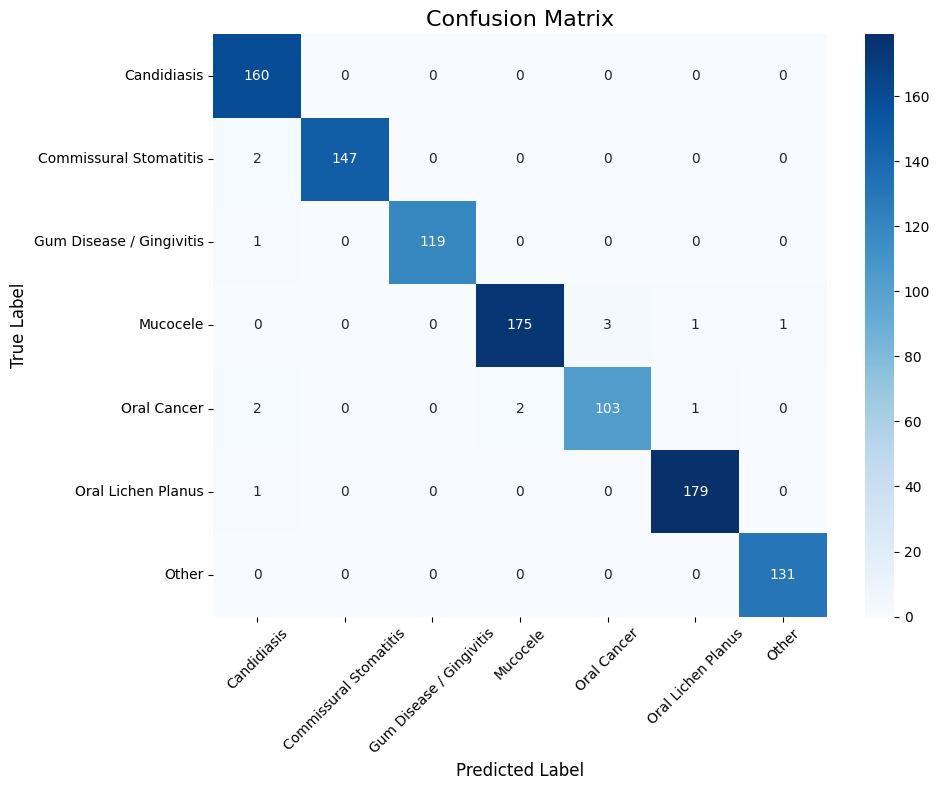

In [10]:
# Cell 10: Confusion Matrix
def plot_confusion_matrix(test_gen, predicted_classes, true_classes, class_mapping):
    if test_gen is None:
        return
    
    print("📈 Plotting confusion matrix...")
    
    # Reverse class_indices
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    
    # Convert numbers to descriptive names
    class_labels = [class_mapping.get(idx_to_class[i], idx_to_class[i]) for i in range(len(idx_to_class))]
    
    # Create confusion matrix
    cm = confusion_matrix(true_classes, predicted_classes)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, 
                yticklabels=class_labels)
    plt.title('Confusion Matrix', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

if test_gen is not None:
    plot_confusion_matrix(test_gen, predicted_classes, true_classes, class_mapping)

In [11]:
# Cell 11: Save the model
def save_model_and_info(model, train_gen, class_mapping):
    print("💾 Saving model and information...")
    
    # Save model
    model.save('oral_disease_classifier_final_final_final.h5')
    print("✅ Model saved as 'oral_disease_classifier_final_final_final.h5'")
    
    # Save class indices for future use
    model_info = {
        'class_indices': train_gen.class_indices,
        'class_mapping': class_mapping,
        'input_shape': (224, 224, 3)
    }
    
    import json
    with open('model_info.json', 'w') as f:
        json.dump(model_info, f, indent=4)
    print("✅ Model info saved as 'model_info.json'")
    
    # Display saved information
    print(f"\n📝 Saved model information:")
    print(f"   - Number of classes: {len(train_gen.class_indices)}")
    print(f"   - Classes: {list(class_mapping.values())}")
    print(f"   - Input shape: 224x224x3")

if train_gen is not None:
    save_model_and_info(model, train_gen, class_mapping)

💾 Saving model and information...
✅ Model saved as 'oral_disease_classifier_final_final_final.h5'
✅ Model info saved as 'model_info.json'

📝 Saved model information:
   - Number of classes: 7
   - Classes: ['Candidiasis', 'Commissural Stomatitis', 'Gum Disease / Gingivitis', 'Mucocele', 'Oral Cancer', 'Oral Lichen Planus', 'Other']
   - Input shape: 224x224x3
